# spliting

In [1]:
!pip install imbalanced-learn


   ---------------------------------------- 0.0/235.4 kB ? eta -:--:--
   ------ -------------------------------- 41.0/235.4 kB 991.0 kB/s eta 0:00:01
   ----------------- ---------------------- 102.4/235.4 kB 1.2 MB/s eta 0:00:01
   -------------------------------------- - 225.3/235.4 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 235.4/235.4 kB 1.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE 
import matplotlib.pyplot as plt
import seaborn as sns
telco = pd.read_csv('C:\\Users\\Abdelrahman\\Desktop\\churn\\Telco_Churn_clean.csv') 

# 2. Drop non-predictive columns if they exist
if 'customerID' in telco.columns:
    telco.drop('customerID', axis=1, inplace=True)

# 3. Final Encoding Pass
# This converts any remaining 'object' columns (like 'gender') into numbers
# to prevent the ValueError: could not convert string to float
telco = pd.get_dummies(telco, drop_first=True)

# 4. Splitting the Data
X = telco.drop('Churn', axis=1)
y = telco['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Apply SMOTE
# Now that all data is numeric, SMOTE will work without errors
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Pre-processing for SMOTE successful.")
print(f"Resampled Training Set Shape: {X_train_res.shape}")

Pre-processing for SMOTE successful.
Resampled Training Set Shape: (8278, 32)


In [4]:
!pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.1/101.7 MB 871.5 kB/s eta 0:01:57
   ---------------------------------------- 0.1/101.7 MB 751.6 kB/s eta 0:02:16
   ---------------------------------------- 0.2/101.7 MB 1.3 MB/s eta 0:01:18
   ---------------------------------------- 0.4/101.7 MB 1.7 MB/s eta 0:01:01
   ---------------------------------------- 0.6/101.7 MB 2.0 MB/s eta 0:00:52
   ---------------------------------------- 1.0/101.7 MB 2.5 MB/s eta 0:00:41
   ---------------------------------------- 1.0/101.7 MB 2.5 MB/s eta 0:00:40
   ---------------------------------------- 1.0/101.7 MB 2.5 MB/s eta 0:00:40
    --------------------------------------- 1.7/101.7 MB 3.0 MB/s eta 0:00:34
    --------------------------------------- 1.7/101.7 MB 3.0 MB/s eta 0:00:34
    --------------------------------------- 1.7/101.7 MB 3.0 MB/s eta 0:00:34
   - -------------------------------------- 2.6/101.7 MB 3.6 MB/s e


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the balance ratio
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

# 2. Train the final optimized model
final_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=ratio,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

final_model.fit(X_train, y_train)

# 3. Predict with 0.5 Threshold
y_probs = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_probs >= 0.5).astype(int)

# 4. Show Results
print(f"Final Accuracy: {accuracy_score(y_test, y_pred_final):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

c:\Users\Abdelrahman\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:00:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Final Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



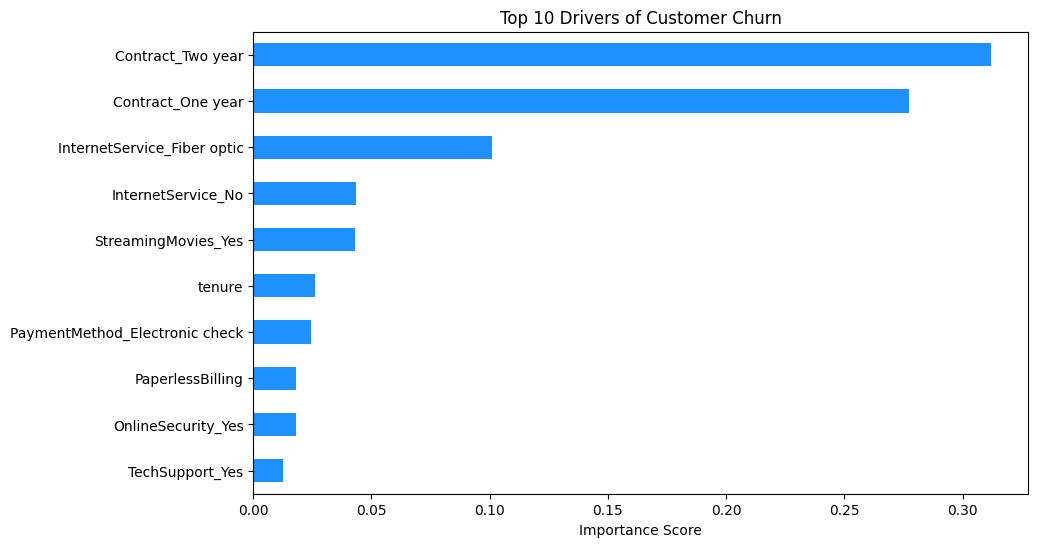

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'final_model' is your XGBoost model
feat_importances = pd.Series(final_model.feature_importances_, index=X.columns)

# Plotting the top 10 features
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='dodgerblue')
plt.title('Top 10 Drivers of Customer Churn')
plt.xlabel('Importance Score')
plt.show()